# Лабораторна робота 2 — Проста лінійна регресія (аналітичний розв'язок)


**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn-регресія **не дозволена** для базових завдань.

## Налаштування

In [32]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline


## Теоретичне підґрунтя

Для однієї вхідної ознаки **x** та виходу **y** аналітичний розв'язок МНК:
```
slope     = ( Σ(xᵢ·yᵢ) − n·x̄·ȳ )  /  ( Σ(xᵢ²) − n·x̄² )
intercept = ȳ − slope · x̄
```
Сума квадратів залишків (RSS):
```
RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²
```

---
## Завдання 1 — Підготовка даних

Завантажте `kc_house_data.csv`. Розбийте на **навчальну (20 %) та тестову (80 %)** вибірки з `random_state=0`.

In [34]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dariatopchii/lab1-mtad-data/kc_house_data (1).csv


In [35]:
sales = pd.read_csv('/kaggle/input/datasets/dariatopchii/lab1-mtad-data/kc_house_data (1).csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)
print(f'Навчальна: {len(train_data)} рядків  |  Тестова: {len(test_data)} рядків')

Навчальна: 4322 рядків  |  Тестова: 17291 рядків


---
## Завдання 2 — Реалізація `simple_linear_regression()`

Завершіть функцію, використовуючи **лише NumPy** (без sklearn, без циклів по рядках).

In [36]:
def simple_linear_regression(input_feature, output):
    """
    Обчислює slope та intercept МНК для однієї ознаки.
    """
    input_feature = np.array(input_feature, dtype=float)
    output = np.array(output, dtype=float)

    x_mean = np.mean(input_feature)
    y_mean = np.mean(output)

    slope = np.sum((input_feature - x_mean) * (output - y_mean)) / np.sum((input_feature - x_mean) ** 2)

    intercept = y_mean - slope * x_mean

    return intercept, slope

### Перевірка — обидва значення нижче мають дорівнювати **1.0**

In [37]:
test_feature = np.arange(5, dtype=float)
test_output  = 1.0 + 1.0 * test_feature
test_intercept, test_slope = simple_linear_regression(test_feature, test_output)
print(f'Intercept: {test_intercept:.4f}  (очікується 1.0)')
print(f'Slope    : {test_slope:.4f}  (очікується 1.0)')


Intercept: 1.0000  (очікується 1.0)
Slope    : 1.0000  (очікується 1.0)


### Навчання на `sqft_living`

In [38]:
sqft_intercept, sqft_slope = simple_linear_regression(
    train_data['sqft_living'], train_data['price']
)
print(f'Вільний член: {sqft_intercept:.2f}')
print(f'Нахил: {sqft_slope:.4f}')


Вільний член: -29748.29
Нахил: 273.5299


---
## Завдання 3 — Передбачення та RSS

**а)** Реалізуйте `get_regression_predictions(input_feature, intercept, slope)` — повертає масив NumPy передбачених значень.  
**б)** Реалізуйте `get_residual_sum_of_squares(input_feature, output, intercept, slope)` — обчислює RSS.  
**в)** Перевірте обидві функції, потім вкажіть RSS на навчальній і тестовій вибірках та дайте відповідь на питання нижче.

In [39]:
def get_regression_predictions(input_feature, intercept, slope):
    input_feature = np.array(input_feature, dtype=float)
    
    predicted_output = intercept + slope * input_feature
    
    return predicted_output

In [40]:
def get_residual_sum_of_squares(input_feature, output, intercept, slope):
    input_feature = np.array(input_feature, dtype=float)
    output = np.array(output, dtype=float)
    
    predictions = get_regression_predictions(input_feature, intercept, slope)
    
    residuals = output - predictions
    
    RSS = np.sum(residuals ** 2)
    
    return RSS

### Перевірка — RSS на тестових вхідних даних має бути **0.0**

In [41]:
rss_check = get_residual_sum_of_squares(
    test_feature, test_output, test_intercept, test_slope
)
print(f'RSS на тестових вхідних даних: {rss_check:.2f}  (очікується 0.0)')


RSS на тестових вхідних даних: 0.00  (очікується 0.0)


### RSS для моделі `sqft_living`

In [42]:
rss_train = get_residual_sum_of_squares(
    train_data['sqft_living'], train_data['price'],
    sqft_intercept, sqft_slope
)
rss_test = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)
print(f'Навчальна RSS: {rss_train:.2e}')
print(f'Тестова  RSS: {rss_test:.2e}')


Навчальна RSS: 2.74e+14
Тестова  RSS: 1.20e+15


### Питання — яка передбачувана ціна будинку площею 2 650 кв. футів?

In [43]:
my_house_sqft = 2650


predicted_price = get_regression_predictions(
    my_house_sqft,
    sqft_intercept,
    sqft_slope
)

print("Передбачувана ціна будинку площею 2650 кв. футів:", predicted_price)

Передбачувана ціна будинку площею 2650 кв. футів: 695105.9804007715


---
## Завдання 4 — Порівняння двох ознак

Навчіть другу модель, використовуючи `bedrooms` як вхідну ознаку. Обчисліть RSS на **тестовій вибірці** для обох моделей (`sqft_living` і `bedrooms`). Яка ознака дає кращий прогноз? Поясніть у 2–3 реченнях.

In [44]:
# Модель 1: sqft_living
intercept_sqft, slope_sqft = simple_linear_regression(
    train_data['sqft_living'],
    train_data['price']
)

# Модель 2: bedrooms
intercept_bedrooms, slope_bedrooms = simple_linear_regression(
    train_data['bedrooms'],
    train_data['price']
)

rss_sqft = get_residual_sum_of_squares(
    test_data['sqft_living'],
    test_data['price'],
    intercept_sqft,
    slope_sqft
)

rss_bedrooms = get_residual_sum_of_squares(
    test_data['bedrooms'],
    test_data['price'],
    intercept_bedrooms,
    slope_bedrooms
)

print("RSS для sqft_living:", rss_sqft)
print("RSS для bedrooms:", rss_bedrooms)

if rss_sqft < rss_bedrooms:
    print("Кращий прогноз дає ознака sqft_living.")
else:
    print("Кращий прогноз дає ознака bedrooms.")

RSS для sqft_living: 1204698183835745.5
RSS для bedrooms: 2150382968642653.2
Кращий прогноз дає ознака sqft_living.


**Відповідь:** Кращий прогноз дає ознака sqft_living, оскільки для неї RSS на тестовій вибірці менше, ніж для ознаки bedrooms. Це логічно, тому що загальна житлова площа будинку зазвичай сильніше пов’язана з його ціною. Кількість спалень також може впливати на вартість, але сама по собі вона не так точно описує розмір і якість будинку.

---
## ✨ Бонус — Зворотна регресія

Реалізуйте `inverse_regression_predictions(output, intercept, slope)`, яка розв'язує рівняння регресії у зворотному напрямку: за цільовою ціною оцінює необхідну площу `sqft_living`. Побудуйте пряму регресії на діаграмі розсіювання навчальних даних і позначте точку ($800 000, ваша відповідь) на графіку.

In [45]:
def inverse_regression_predictions(output, intercept, slope):
    predicted_input = (output - intercept) / slope
    
    return predicted_input


In [46]:
house_price = 800000

estimated_sqft = inverse_regression_predictions(
    house_price,
    intercept_sqft,
    slope_sqft
)

print(f"Орієнтовна площа будинку для ціни $800 000: {estimated_sqft:.2f} кв. футів")

Орієнтовна площа будинку для ціни $800 000: 3033.48 кв. футів


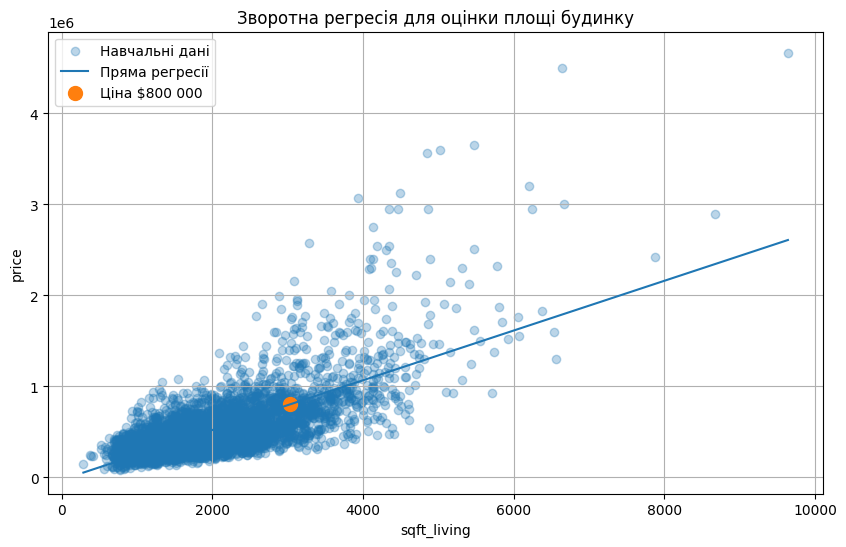

Для ціни $800 000 орієнтовна площа: 3033.48 кв. футів


In [47]:
import matplotlib.pyplot as plt
import numpy as np

house_price = 800000

estimated_sqft = inverse_regression_predictions(
    house_price,
    intercept_sqft,
    slope_sqft
)

# Дані для прямої регресії
x_line = np.linspace(
    train_data['sqft_living'].min(),
    train_data['sqft_living'].max(),
    100
)

y_line = get_regression_predictions(
    x_line,
    intercept_sqft,
    slope_sqft
)

plt.figure(figsize=(10, 6))

plt.scatter(
    train_data['sqft_living'],
    train_data['price'],
    alpha=0.3,
    label='Навчальні дані'
)

plt.plot(
    x_line,
    y_line,
    label='Пряма регресії'
)

plt.scatter(
    estimated_sqft,
    house_price,
    s=100,
    label='Ціна $800 000'
)

plt.xlabel('sqft_living')
plt.ylabel('price')
plt.title('Зворотна регресія для оцінки площі будинку')
plt.legend()
plt.grid(True)

plt.show()

print(f"Для ціни $800 000 орієнтовна площа: {estimated_sqft:.2f} кв. футів")